# HelleniFlex — Interactive Demo

This notebook walks through the framework end-to-end. Run all cells from top to bottom.

**Estimated runtime:** ~30 seconds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helleniflex import (
    BatteryAsset, BatteryOptimizer, Backtester,
    PerfectForesightForecaster, NaiveForecaster, SmartForecaster,
    make_synthetic_greek_dam_prices, PRESETS,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load price data

We use the synthetic Greek DAM price generator for a self-contained demo. Switch to `load_csv_prices()` or `fetch_entsoe_dam()` for real data.

In [2]:
prices = make_synthetic_greek_dam_prices(start='2024-01-01', end='2025-12-31')
print(f'{len(prices):,} 15-min price points from {prices.index[0]} to {prices.index[-1]}')
prices.head()

70,081 15-min price points from 2024-01-01 00:00:00 to 2025-12-31 00:00:00


2024-01-01 00:00:00    149.157708
2024-01-01 00:15:00    138.398686
2024-01-01 00:30:00    152.720742
2024-01-01 00:45:00    154.240222
2024-01-01 01:00:00    131.106019
Freq: 15min, Name: dam_price_eur_mwh, dtype: float64

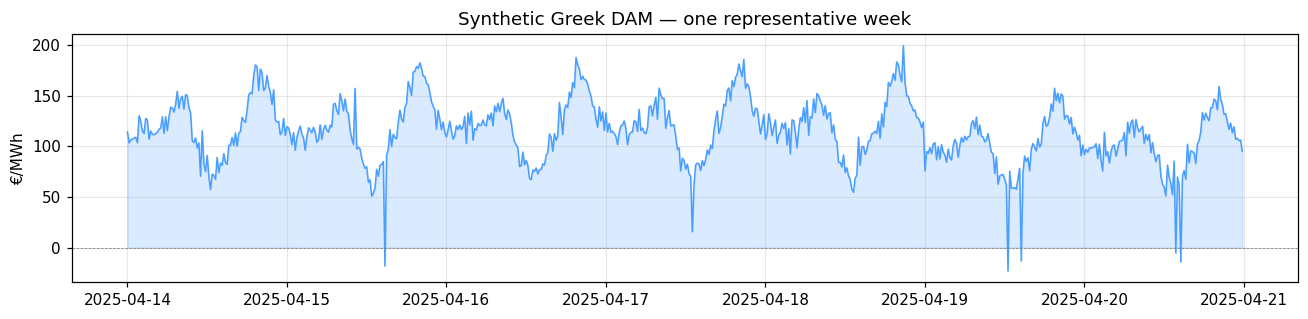

In [3]:
# Plot a representative week
week = prices.loc['2025-04-14':'2025-04-20']
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(week.index, week.values, color='#4a9eff', lw=1)
ax.fill_between(week.index, week.values, alpha=0.2, color='#4a9eff')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_ylabel('€/MWh'); ax.set_title('Synthetic Greek DAM — one representative week')
plt.tight_layout()

## 2. Define an asset

The `BatteryAsset` dataclass captures every parameter the optimizer needs. Use a preset or define your own.

In [4]:
battery = PRESETS['greek_standalone_2h']
print(battery.summary())
battery

Greek Standalone 2h BESS: 1.0 MW / 2.0 MWh (2.0h), η_RT=88%, SoC 10%–90%


BatteryAsset(name='Greek Standalone 2h BESS', power_mw=1.0, capacity_mwh=2.0, eta_charge=0.94, eta_discharge=0.94, soc_min_pct=0.1, soc_max_pct=0.9, initial_soc_pct=0.5, daily_cycle_limit=1.5, cycle_cost_eur_per_mwh=3.0, min_dispatch_mw=0.0)

## 3. Single-day MILP optimization

In [5]:
opt = BatteryOptimizer(battery)
day = '2025-04-15'  # a spring day with negative-price slots
result = opt.optimize(prices.loc[day].values, dt_hours=0.25)
print(f'Status: {result.status}')
print(f'Revenue: €{result.revenue_eur:.2f}')
print(f'Cycles:  {result.cycles:.2f}')

Status: optimal
Revenue: €193.06
Cycles:  1.50


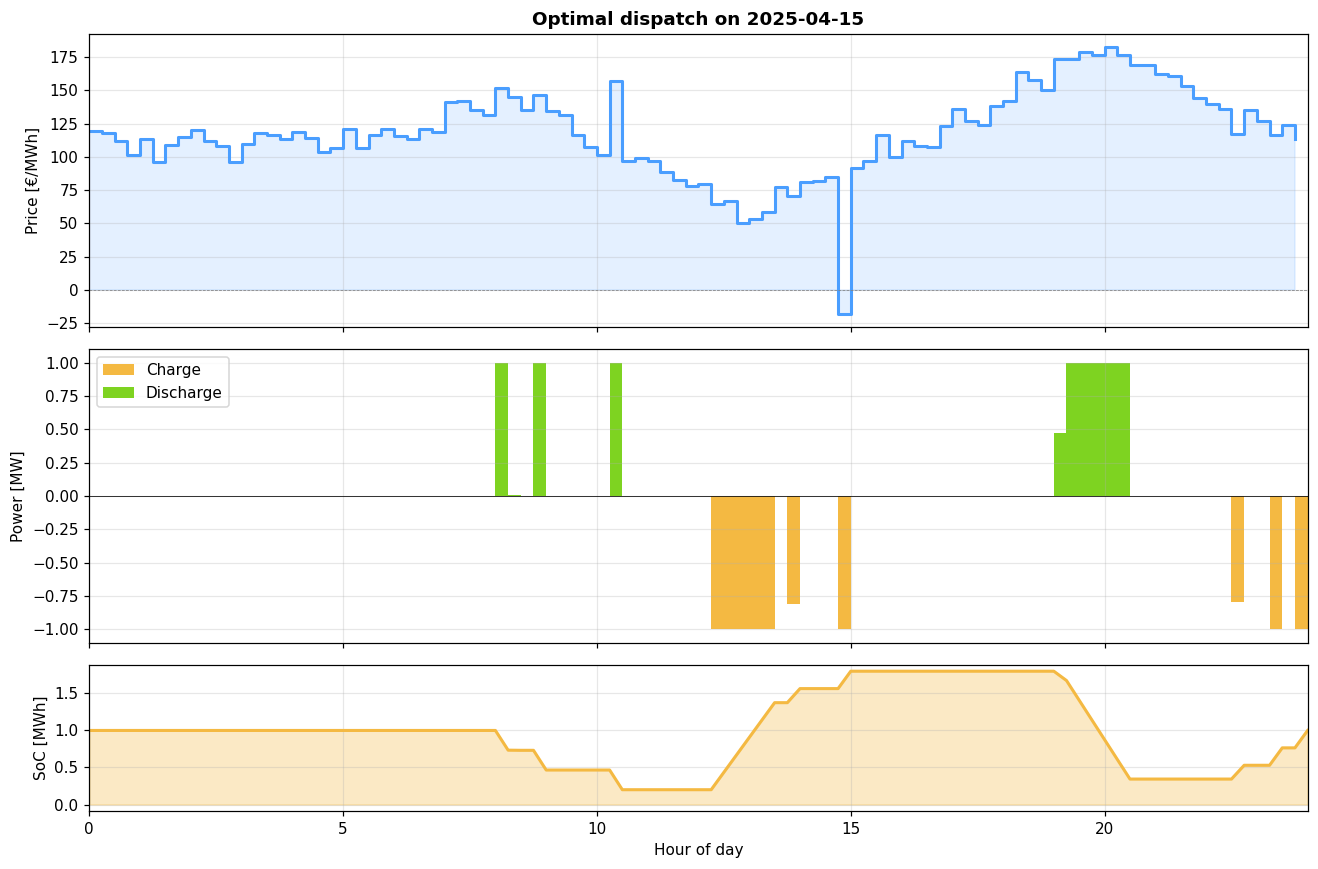

In [6]:
# The signature dispatch chart
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 2, 1]})
h = np.arange(96) * 0.25

axes[0].plot(h, result.prices, color='#4a9eff', lw=2, drawstyle='steps-post')
axes[0].fill_between(h, result.prices, alpha=0.15, color='#4a9eff', step='post')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].set_ylabel('Price [€/MWh]')
axes[0].set_title(f'Optimal dispatch on {day}', fontweight='bold')

axes[1].bar(h, -result.charge_mw, width=0.25, color='#f4b942', label='Charge', align='edge')
axes[1].bar(h, result.discharge_mw, width=0.25, color='#7ed321', label='Discharge', align='edge')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Power [MW]'); axes[1].legend(loc='upper left')

axes[2].plot(np.arange(97)*0.25, result.soc_mwh, color='#f4b942', lw=2)
axes[2].fill_between(np.arange(97)*0.25, result.soc_mwh, alpha=0.3, color='#f4b942')
axes[2].set_ylabel('SoC [MWh]'); axes[2].set_xlabel('Hour of day')
axes[2].set_xlim(0, 24)
plt.tight_layout()

## 4. Backtest with three forecasters

Honest evaluation: each day, the forecaster sees only history before that day, then we settle the resulting schedule at actual prices.

In [7]:
results = {}
for fc_cls in (PerfectForesightForecaster, NaiveForecaster, SmartForecaster):
    fc = fc_cls()
    bt = Backtester(battery, forecaster=fc)
    res = bt.run(prices, start='2025-05-01', end='2025-05-30')
    results[fc.name] = res
    print(res.summary())

[Greek Standalone 2h BESS | Perfect Foresight]  days=30  total=€5,657  avg/day=€189  €/MWh/yr=34,416  cycles/day=1.50
[Greek Standalone 2h BESS | Naive (last-week)]  days=30  total=€4,440  avg/day=€148  €/MWh/yr=27,010  cycles/day=1.50
[Greek Standalone 2h BESS | Smart (Ridge + calendar)]  days=30  total=€4,964  avg/day=€165  €/MWh/yr=30,198  cycles/day=1.50


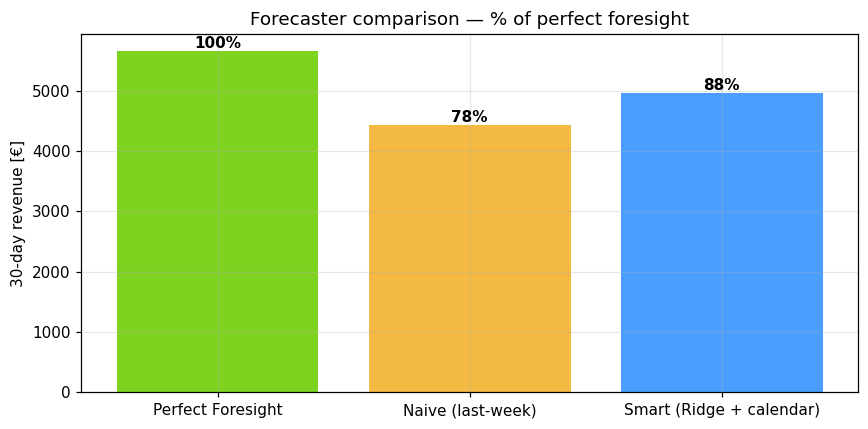

In [8]:
# Bar chart comparison
names = list(results.keys())
totals = [r.total_revenue_eur for r in results.values()]
pf = totals[0]
pcts = [t / pf * 100 for t in totals]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#7ed321', '#f4b942', '#4a9eff']
bars = ax.bar(names, totals, color=colors)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.0f}%', ha='center', fontweight='bold')
ax.set_ylabel('30-day revenue [€]')
ax.set_title('Forecaster comparison — % of perfect foresight')
plt.tight_layout()

## 5. Asset sensitivity

Same window, perfect foresight, three battery durations.

In [9]:
duration_results = []
for preset_name in ['greek_standalone_1h', 'greek_standalone_2h', 'greek_standalone_4h']:
    bt = Backtester(PRESETS[preset_name], forecaster=PerfectForesightForecaster())
    res = bt.run(prices, start='2025-05-01', end='2025-05-30')
    duration_results.append({
        'name': PRESETS[preset_name].name,
        'duration_h': PRESETS[preset_name].duration_hours,
        'eur_per_day': res.avg_daily_revenue_eur,
        'eur_per_mwh_per_year': res.revenue_per_mwh_per_year,
    })
pd.DataFrame(duration_results)

,name,duration_h,eur_per_day,eur_per_mwh_per_year
0,Greek Standalone 1h BESS,1.0,109.506354,39969.819333
1,Greek Standalone 2h BESS,2.0,188.578654,34415.604394
2,Greek Standalone 4h BESS,4.0,259.515499,23680.789323


## 6. Forecast-error sensitivity

Add Gaussian noise to perfect-foresight forecasts and watch revenue degrade. The slope of this curve is exactly what an investor needs to know.

   forecast_sigma_eur_mwh  monthly_revenue_eur
0                       0          5657.359626
1                       5          5528.576421
2                      10          5216.508850
3                      20          4478.258149
4                      30          3914.174490
5                      50          2659.014861


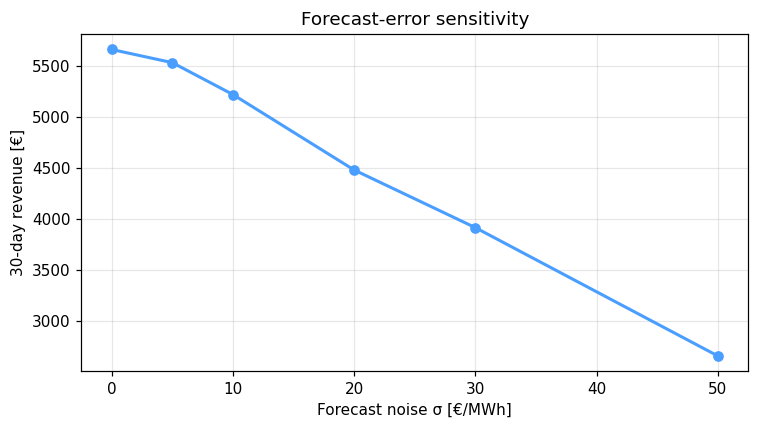

In [10]:
rng = np.random.default_rng(0)
noise_levels = [0, 5, 10, 20, 30, 50]
rows = []
for sigma in noise_levels:
    rev = 0.0
    days = pd.date_range('2025-05-01', '2025-05-30', freq='D')
    for day in days:
        actual = prices.loc[day.strftime('%Y-%m-%d')].values
        forecast = actual + rng.normal(0, sigma, len(actual))
        sched = opt.optimize(forecast, dt_hours=0.25)
        rev += BatteryOptimizer.settle(sched, actual)
    rows.append({'forecast_sigma_eur_mwh': sigma, 'monthly_revenue_eur': rev})
df = pd.DataFrame(rows)
print(df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df['forecast_sigma_eur_mwh'], df['monthly_revenue_eur'], 'o-', color='#4a9eff', lw=2)
ax.set_xlabel('Forecast noise σ [€/MWh]')
ax.set_ylabel('30-day revenue [€]')
ax.set_title('Forecast-error sensitivity')
plt.tight_layout()